# Detector Diffusion MTF: Numerical Examples

This notebook uses the diffusion MTF equations derived in the [`Detector Diffusion MTF Derivation Notebook`](detector_diffusion_derivation.ipynb) with realistic detector parameters to explore how different detector types and operating conditions affect the diffusion MTF.

## Physics Background

A photon absorbed in a silicon detector generates an electron that must travel to the collection node (pixel gate). The path it takes determines how much lateral spreading — and therefore MTF degradation — occurs.

**Field-free region ($L_a$):** No electric field is present, so the carrier moves by Brownian motion (random walk). Lateral spreading is proportional to $L_a$. This is the source of diffusion blur.

**Depletion region ($L_b$):** An internal electric field sweeps the carrier vertically toward the gate. Lateral motion is negligible — the field acts as a guide rail. The depletion region is effectively a perfect sink: once a carrier reaches its edge, it is collected almost instantaneously.

 In front-side illuminated sensors, photons first pass through the depletion region ($L_b$), then reach the field-free bulk ($L_a$). The geometry is reversed relative to BSI, but the physics is the same: $L_a$ drives diffusion blur.

All MTF degradation therefore occurs in the field-free region. The design goal is $L_a \ll p$ (pixel pitch). If $L_a > p$ in a BSI sensor without deep-trench isolation (DTI), significant charge sharing between adjacent pixels is expected.

The two dominant design trade-offs are: (1) **sharpness** — if $L_a > p$, the sensor is diffusion-limited and significant inter-pixel crosstalk occurs; (2) **sensitivity** — if $S$ is large, carriers are lost at the surface before collection, reducing QE. Modern scientific sensors address both by minimising $L_a$ through back-thinning and minimising $S$ through surface passivation or delta-doping. In practice, manufacturers shrink the field-free region by (1) physically thinning the detector so the epi layer is only a few microns thick, or (2) back-biasing — applying a voltage to push the depletion boundary deeper into the bulk, converting field-free material into depleted material.

**Deep depletion:** When the sensor is fully depleted ($L_a \approx 0$), there is no field-free region and diffusion MTF $\approx 1$. The entire silicon thickness is swept by the field.

**Surface recombination ($S$):** $S \to \infty$ (dead surface) means carriers that reach the illuminated surface are immediately lost — a hard absorbing boundary. $S = 0$ (passivated surface) means carriers reflect off the back surface and remain in $L_a$ until collected. Passivation increases sensitivity but also increases the effective dwell time in the field-free region.

## Detector Types and Typical Parameter Ranges

| Detector Type | Geometry | $S$ | $L_a$ (field-free) | $L_b$ (depletion) | Pixel Pitch | Model | Example |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Sci-CCD (BSI)** | Field Free → Depletion | $S \to \infty$ | 15–20 µm | 10–20 µm | 13 µm | BSI-1 | Teledyne e2v CCD47-10 |
| **sCMOS (BSI)** | Field Free → Depletion | $S \approx 0$ | 3–8 µm | 1–2 µm | 6.5–11 µm | BSI-2 | Gpixel GSENSE400BSI |
| **MCT IR (BSI)** | Field Free → Depletion | Finite | 10–30 µm | $L_b \to \infty$ | 18 µm | BSI-3 | Teledyne H2RG |
| **Deep Depletion CCD** | Full Depletion | N/A | $L_a \approx 0$ | 40–100 µm | 13.5 µm | MTF = 1 | Teledyne e2v CCD42-90 DD |
| **Consumer FSI** | Depletion → Field Free | Finite | 50–200 µm | 1–2 µm | 5.86 µm | FSI-1 / FSI-2 | Sony IMX174 |

**MCT note:** HgCdTe infrared detectors must be operated at cryogenic temperatures (typically 77 K for MWIR/LWIR). Without cooling, the narrow bandgap of MCT results in thermal carrier generation that overwhelms the photocurrent signal.

## References

- Teledyne e2v CCD47-10 BSI datasheet: <https://www.teledynespaceimaging.com/en-us/Products_/Documents/ccd-datasheets/CCD47-10%20BSI%20Datasheet%20(v1).pdf>
- Gpixel GSENSE400BSI product page: <https://www.gpixel.com/en/pro_details_1195.html>
- Teledyne H2RG brochure: <https://www.teledyne-si.com/en-us/Products-and-Services_/Documents/Infrared%20and%20Visible%20FPAs/TSI-0855%20H2RG%20Brochure-25Feb2022.pdf>
- Sony IMX174 datasheet: <https://s1-dl.theimagingsource.com/api/2.5/packages/publication/sensor-sony/imx174llj/09834263-2e7f-5fdc-acc2-8b222d8bd575/imx174llj_1.0.en_US.pdf>
- Teledyne e2v CCD42-90 DD datasheet: <https://www.ucolick.org/~sla/fits/mosaic/panes/14-42-90-DD-BI-NIMO-ButtablePkg.pdf>


## Summary of Models

All models are derived from the **Crowell & Labuda (1969)** general diffusion equation (Eq. 5). The key distinction is the **light direction**:

- **BSI (Back-Side Illuminated):** Light enters the field-free region first, then reaches the depletion region. This is the original C&L geometry.
- **FSI (Front-Side Illuminated):** Light enters the depletion region first. This requires a reversed-geometry derivation from first principles.

### BSI Models (C&L geometry: Field-Free → Depletion)

| Model | Assumptions | Detector Type | Equation |
|------|-------------|---------------|----------|
| 1 | $S \to \infty$, $R = 0$ | Scientific CCD (thinned BSI, dead surface) | $\eta_k = \frac{\alpha L}{\alpha^2 L^2 - 1}\left[\frac{1 - \cosh\xi\cdot e^{-\alpha L_a}}{\sinh\xi} - \frac{e^{-\alpha L_a}}{\alpha L}\right] - e^{-\alpha L_b}$ |
| 2 | $S = 0$, $R = 0$ | sCMOS (BSI, passivated) | $\eta_k = \frac{\alpha L}{\alpha^2 L^2 - 1}\left[\alpha L\,\text{sech}\,\xi - \tanh\xi\cdot e^{-\alpha L_a} - \frac{e^{-\alpha L_a}}{\alpha L}\right] - e^{-\alpha L_b}$ |
| 3 | $R = 0$, $L_b \to \infty$, general $S$ | MCT infrared (thick substrate) | $\eta_k = \frac{\alpha L}{\alpha^2 L^2 - 1}\left[\frac{\alpha L + SL/D}{\cosh\xi + (SL/D)\sinh\xi} - \frac{\sinh\xi + (SL/D)\cosh\xi}{\cosh\xi + (SL/D)\sinh\xi}\cdot e^{-\alpha L_a} - \frac{e^{-\alpha L_a}}{\alpha L}\right]$ |

### FSI Models (Reversed C&L: Depletion → Field-Free)

| Model | Assumptions | Detector Type | Equation |
|------|-------------|---------------|----------|
| 1 | $S \to \infty$, $R = 0$, finite $L_a$ | Standard CCD/CMOS (FSI, finite substrate) | $\eta_k = (1 - e^{-\alpha L_D}) + \eta_{\text{ff},k}$ |
| 2 | $S \to \infty$, $R = 0$, $L_a \to \infty$ | Bulk CCD/CMOS (FSI, thick substrate) | $\eta_k = 1 - \frac{e^{-\alpha L_D}}{1 + \alpha L}$ |

### Deep Depletion CCD

No field-free region → diffusion MTF = 1 at all frequencies.

### Common definitions

- $L = L_o / \sqrt{1 + k^2 L_o^2}$: frequency-dependent diffusion length
- $\xi = L_a / L$
- $k = 2\pi f$ where $f$ is spatial frequency
- $L_o = \sqrt{D\tau}$: zero-frequency (DC) diffusion length
- MTF$_{\text{diff}}(f) = \eta_k / \eta_0$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# --- BSI-1: S -> inf, R = 0 (Scientific CCD, dead surface) ---
def bsi_case1_eta(f, alpha, L_o, L_a, L_b):
    """BSI collection efficiency: dead surface, no reflection."""
    k = 2 * np.pi * f
    L = L_o / np.sqrt(1 + k**2 * L_o**2)
    xi = L_a / L
    aL = alpha * L
    return aL / (aL**2 - 1) * (
        (1 - np.cosh(xi) * np.exp(-alpha * L_a)) / np.sinh(xi)
        - np.exp(-alpha * L_a) / aL
    ) - np.exp(-alpha * L_b)


# --- BSI-2: S = 0, R = 0 (sCMOS, passivated surface) ---
def bsi_case2_eta(f, alpha, L_o, L_a, L_b):
    """BSI collection efficiency: passivated surface, no reflection."""
    k = 2 * np.pi * f
    L = L_o / np.sqrt(1 + k**2 * L_o**2)
    xi = L_a / L
    aL = alpha * L
    return aL / (aL**2 - 1) * (
        aL / np.cosh(xi)
        - np.tanh(xi) * np.exp(-alpha * L_a)
        - np.exp(-alpha * L_a) / aL
    ) - np.exp(-alpha * L_b)


# --- BSI-3: R = 0, L_b -> inf, general S (MCT thick substrate) ---
def bsi_case3_eta(f, alpha, L_o, L_a, S, D):
    """BSI collection efficiency: thick substrate, general S."""
    k = 2 * np.pi * f
    L = L_o / np.sqrt(1 + k**2 * L_o**2)
    xi = L_a / L
    aL = alpha * L
    sLD = S * L / D
    cxi, sxi = np.cosh(xi), np.sinh(xi)
    denom = cxi + sLD * sxi
    return (
        aL
        / (aL**2 - 1)
        * (
            (aL + sLD) / denom
            - (sxi + sLD * cxi) / denom * np.exp(-alpha * L_a)
            - np.exp(-alpha * L_a) / aL
        )
    )


# --- FSI-1: Reversed C&L, S -> inf, finite L_a ---
def fsi_case4_eta(f, alpha, L_o, L_a, L_D):
    """FSI collection efficiency: dead far surface, finite substrate."""
    k = 2 * np.pi * f
    L = L_o / np.sqrt(1 + k**2 * L_o**2)
    xi = L_a / L
    aL = alpha * L
    eta_dep = 1 - np.exp(-alpha * L_D)
    P = aL * L / (aL**2 - 1) * np.exp(-alpha * L_D)
    A = P * (np.cosh(xi) - np.exp(-alpha * L_a)) / np.sinh(xi)
    eta_ff = -(A / L - alpha * P)
    return eta_dep + eta_ff


# --- FSI-2: Reversed C&L, S -> inf, L_a -> inf (semi-infinite) ---
def fsi_case5_eta(f, alpha, L_o, L_D):
    """FSI collection efficiency: dead far surface, semi-infinite substrate."""
    k = 2 * np.pi * f
    L = L_o / np.sqrt(1 + k**2 * L_o**2)
    return 1 - np.exp(-alpha * L_D) / (1 + alpha * L)


def eta_to_mtf(eta_func, f, *args):
    """Compute normalised MTF = eta(f) / eta(0)."""
    eta = eta_func(f, *args)
    eta0 = eta_func(np.array([1e-13]), *args)[0]
    return eta / eta0


print("Model functions defined.")

Model functions defined.


## Detector Parameters

Representative parameters drawn from the literature:
- **Silicon absorption:** Green (2008), *Solar Energy Materials and Solar Cells*
- **Scientific CCD:** Janesick (2001), *Scientific Charge-Coupled Devices*; Hopkinson (1987)
- **sCMOS:** Hamamatsu, Andor datasheets; typical thin-epi BSI architecture
- **MCT:** Rogalski (2019), *Infrared Detectors*; Chu et al. (1994)
- **Diffusion lengths & coefficients:** Sze & Ng (2007), *Physics of Semiconductor Devices*
- **Surface recombination:** Nikzad et al. (JPL delta-doping); Stern et al. (1994)

In [ ]:
# === Silicon absorption coefficient alpha (um^-1) at 300 K (Green 2008) ===
si_alpha = {
    400: 5.0,
    450: 2.78,
    500: 1.0,
    550: 0.63,
    600: 0.40,
    650: 0.27,
    700: 0.19,
    750: 0.13,
    800: 0.089,
    850: 0.058,
    900: 0.036,
    950: 0.019,
    1000: 0.010,
}

# === MCT absorption coefficient alpha (um^-1) at 77 K (Rogalski 2019, Chu 1994) ===
mct_mwir_alpha = {
    2.0: 1.5,
    3.0: 0.8,
    4.0: 0.5,
    4.5: 0.3,
    4.8: 0.15,
}  # x~0.30, cutoff ~5 um
mct_lwir_alpha = {
    5.0: 1.0,
    8.0: 0.5,
    10.0: 0.3,
    11.0: 0.2,
    11.5: 0.1,
}  # x~0.22, cutoff ~12 um

# === Detector parameter sets ===

# Teledyne e2v CCD47-10 (BSI-1: thinned, dead surface)
# Janesick (2001): thinned epi ~15-20 um field-free, depletion ~10-20 um, L_Diff ~ 100-300 um
sci_ccd = {
    "name": "e2v CCD47-10 (BSI)",
    "L_o": 200,
    "L_a": 17,
    "L_b": 15,
    "pitch": 13,
    "model": "bsi_case1",
}

# Gpixel GSENSE400BSI (BSI-2: thin epi, passivated back surface)
# Thin epi ~3-8 um, depletion ~1-2 um, L_Diff ~ 10-30 um
scmos = {
    "name": "GSENSE400BSI (BSI)",
    "L_o": 20,
    "L_a": 5,
    "L_b": 1.5,
    "pitch": 6.5,
    "model": "bsi_case2",
}

# Generic FSI CCD — thick bulk substrate, semi-infinite (FSI-2)
# Representative of older FSI CCDs: L_Diff ~ 30-100 um, L_D ~ 2-4 um, pitch ~13 um
std_ccd = {
    "name": "FSI CCD (generic)",
    "L_o": 50,
    "L_D": 3,
    "pitch": 13.0,
    "model": "fsi_case5",
}

# Sony IMX174 (FSI-1: finite bulk substrate)
# Pregius Gen 1: L_Diff ~ 10-30 um, L_D ~ 1-2 um, pitch=5.86 um
std_cmos = {
    "name": "Sony IMX174 (FSI)",
    "L_o": 15,
    "L_a": 3,
    "L_D": 2,
    "pitch": 5.86,
    "model": "fsi_case4",
}

# Teledyne H2RG MWIR (BSI-3: thick MCT substrate, general S)
# Rogalski (2019): L_Diff 10-30 um, absorber ~7 um, S ~ 500 cm/s passivated, pitch=18 um
mct_mwir = {
    "name": "H2RG MWIR",
    "L_o": 25,
    "L_a": 7,
    "S": 500,
    "D": 15,
    "pitch": 18,
    "model": "bsi_case3",
}

# Teledyne H2RG LWIR (BSI-3: thick MCT substrate, general S)
# Rogalski (2019): L_Diff 15-50 um, absorber ~10 um, D ~ 20-100 cm^2/s, pitch=18 um
mct_lwir = {
    "name": "H2RG LWIR",
    "L_o": 35,
    "L_a": 10,
    "S": 1000,
    "D": 40,
    "pitch": 18,
    "model": "bsi_case3",
}

print("Parameters defined.\n")
for d in [sci_ccd, scmos, std_ccd, std_cmos, mct_mwir, mct_lwir]:
    print(
        f"  {d['name']}: L_o={d['L_o']} µm, pitch={d['pitch']} µm, model={d['model']}"
    )

Parameters defined.

  e2v CCD47-10 (BSI): L_o=200 µm, pitch=13 µm, model=bsi_case1
  GSENSE400BSI (BSI): L_o=20 µm, pitch=6.5 µm, model=bsi_case2
  FSI CCD (generic): L_o=50 µm, pitch=13.0 µm, model=fsi_case5
  Sony IMX174 (FSI): L_o=15 µm, pitch=5.86 µm, model=fsi_case4
  H2RG MWIR: L_o=25 µm, pitch=18 µm, model=bsi_case3
  H2RG LWIR: L_o=35 µm, pitch=18 µm, model=bsi_case3


## Analysis

### Silicon Detectors: Wavelength Dependence

Compare the diffusion MTF of BSI Scientific CCD, BSI sCMOS, FSI Standard CCD, and FSI Standard CMOS across visible/NIR wavelengths. The key physics:

- **BSI:** Short wavelengths (blue) are absorbed near the back surface, far from the depletion region → more diffusion → worse MTF.
- **FSI:** Short wavelengths are absorbed near the depletion region → less diffusion → better MTF. Long wavelengths penetrate deep → worse MTF.

This is the fundamental BSI/FSI asymmetry.

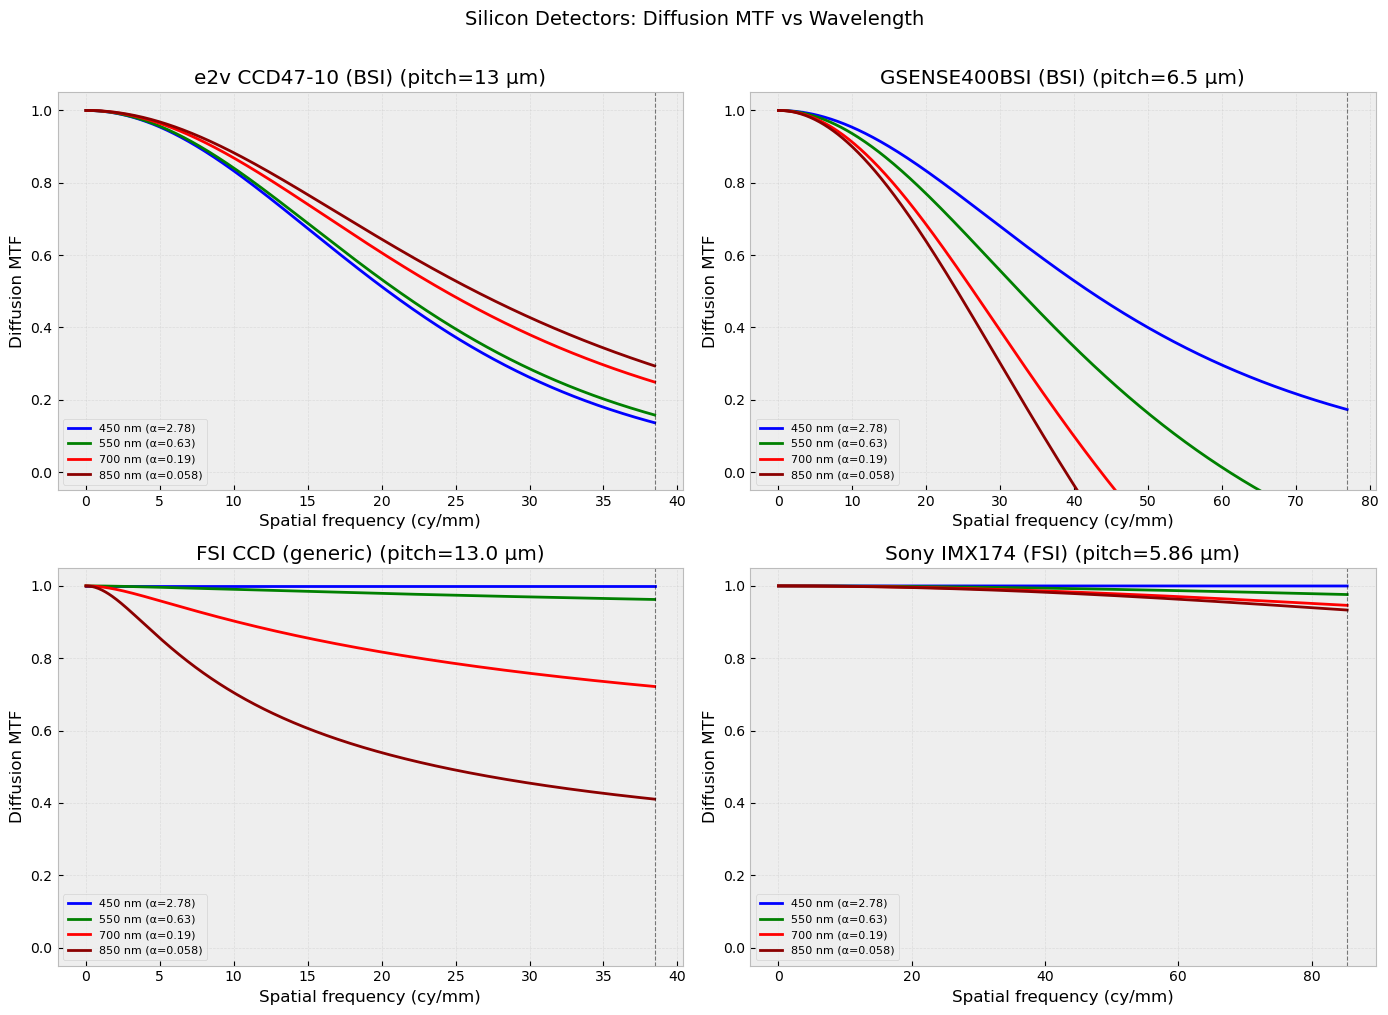

In [ ]:
wavelengths_nm = [450, 550, 700, 850]
colors = {450: "blue", 550: "green", 700: "red", 850: "darkred"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
detectors_si = [
    (sci_ccd, axes[0, 0]),
    (scmos, axes[0, 1]),
    (std_ccd, axes[1, 0]),
    (std_cmos, axes[1, 1]),
]

for det, ax in detectors_si:
    f_ny = 1000 / (2 * det["pitch"])
    f = np.linspace(0.01, f_ny, 500)

    for wl in wavelengths_nm:
        alpha = si_alpha[wl]

        if det["model"] == "bsi_case1":
            mtf = eta_to_mtf(
                bsi_case1_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_b"]
            )
        elif det["model"] == "bsi_case2":
            mtf = eta_to_mtf(
                bsi_case2_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_b"]
            )
        elif det["model"] == "fsi_case5":
            mtf = eta_to_mtf(fsi_case5_eta, f / 1000, alpha, det["L_o"], det["L_D"])
        elif det["model"] == "fsi_case4":
            mtf = eta_to_mtf(
                fsi_case4_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_D"]
            )

        ax.plot(f, mtf, color=colors[wl], label=f"{wl} nm (α={alpha})")

    ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{det['name']} (pitch={det['pitch']} µm)")
    ax.set_xlabel("Spatial frequency (cy/mm)")
    ax.set_ylabel("Diffusion MTF")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Silicon Detectors: Diffusion MTF vs Wavelength", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

**Key observations:**

- **BSI at short wavelengths (450 nm):** MTF is severely degraded. Blue photons are absorbed within ~1 µm of the back surface and must diffuse the entire field-free layer $L_a$ to reach the depletion region. The e2v CCD47-10 with $L_a = 17$ µm shows the worst MTF here; the GSENSE400BSI with its thin epi ($L_a = 5$ µm) fares much better.
- **BSI at long wavelengths (850 nm):** NIR photons penetrate deeply and are absorbed within or near the depletion region — diffusion path is short and MTF recovers toward 1.
- **FSI at short wavelengths (450 nm):** The opposite behaviour. Blue photons are absorbed just inside the front surface, immediately adjacent to the depletion region, so diffusion is minimal and MTF is high.
- **FSI at long wavelengths (850 nm):** NIR photons penetrate through the thin depletion layer into the thick field-free bulk. Now the FSI suffers the same long diffusion path that plagues BSI at blue wavelengths, and MTF degrades.
- **Crossover:** Each detector has a wavelength at which MTF is best; BSI detectors peak in the NIR, FSI detectors peak in the blue/visible. This is the BSI/FSI trade-off.


### BSI: Dead Surface vs Passivated Surface

Compare BSI-1 ($S \to \infty$) and BSI-2 ($S = 0$) with the same structural parameters to isolate the effect of surface recombination. We use the e2v CCD47-10 geometry ($L_a = 17$ µm, $L_b = 3$ µm, pitch = 13 µm) since its relatively large field-free region makes the difference between the two boundary conditions clearly visible.

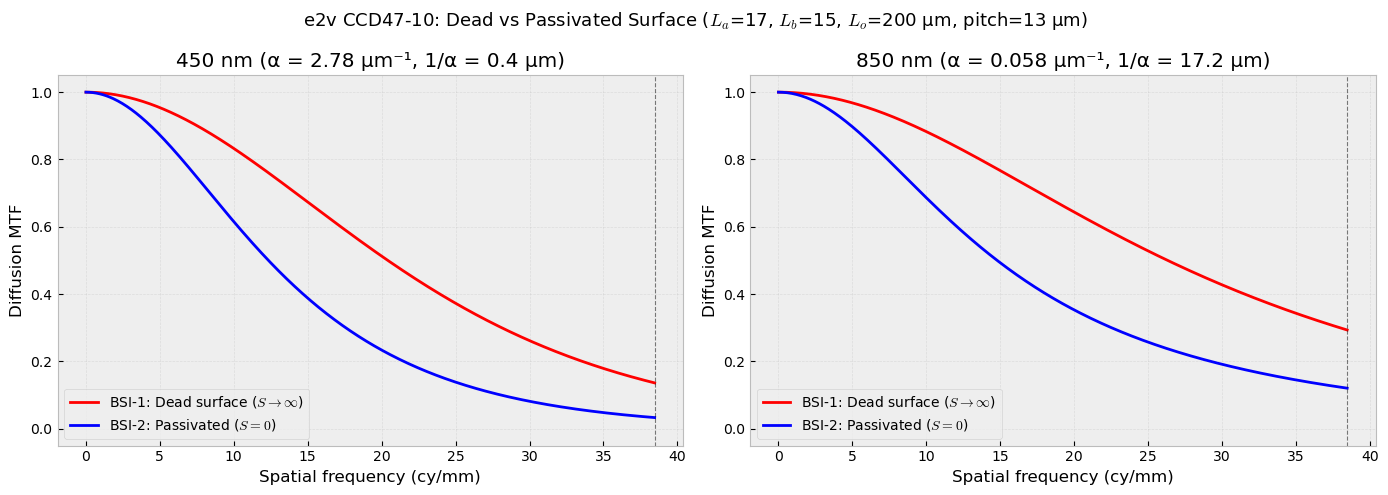

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# e2v CCD47-10 geometry
L_a = sci_ccd["L_a"]  # 17 um
L_b = sci_ccd["L_b"]  # 3 um
L_o = sci_ccd["L_o"]  # 200 um
pitch = sci_ccd["pitch"]  # 13 um
f_ny = 1000 / (2 * pitch)
f = np.linspace(0.01, f_ny, 500)

for wl, ax in zip([450, 850], axes, strict=False):
    alpha = si_alpha[wl]
    mtf_dead = eta_to_mtf(bsi_case1_eta, f / 1000, alpha, L_o, L_a, L_b)
    mtf_pass = eta_to_mtf(bsi_case2_eta, f / 1000, alpha, L_o, L_a, L_b)

    ax.plot(f, mtf_dead, "r-", label="BSI-1: Dead surface ($S \\to \\infty$)")
    ax.plot(f, mtf_pass, "b-", label="BSI-2: Passivated ($S = 0$)")

    ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{wl} nm (α = {alpha} µm⁻¹, 1/α = {1 / alpha:.1f} µm)")
    ax.set_xlabel("Spatial frequency (cy/mm)")
    ax.set_ylabel("Diffusion MTF")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"e2v CCD47-10: Dead vs Passivated Surface "
    f"($L_a$={L_a}, $L_b$={L_b}, $L_o$={L_o} µm, pitch={pitch} µm)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

**Key observations:**

- **At 450 nm (blue):** BSI-1 (dead surface, $S \to \infty$) shows very low MTF — carriers generated near the back surface recombine before reaching the depletion region. BSI-2 (perfect passivation, $S = 0$) performs dramatically better: the back surface acts as a mirror for minority carriers, reflecting them toward the junction.
- **At 850 nm (NIR):** Photons are absorbed deep in the silicon, far from the back surface, so the surface recombination boundary condition matters much less. Both BSI-1 and BSI-2 converge to similar MTF values.
- **Practical implication:** Back-surface passivation is critical for UV/blue sensitivity in BSI sensors. This is why scientific CCDs and sCMOS sensors employ careful surface treatments (e.g., delta doping, chemisorption, molecular beam epitaxy) to suppress $S$. Without it, a BSI sensor loses most of its blue quantum efficiency.


### BSI: Effect of Field-Free Region Thickness ($L_a$)

Thinning the substrate reduces $L_a$ and improves diffusion MTF. This is why BSI sCMOS sensors use thin epitaxial layers.

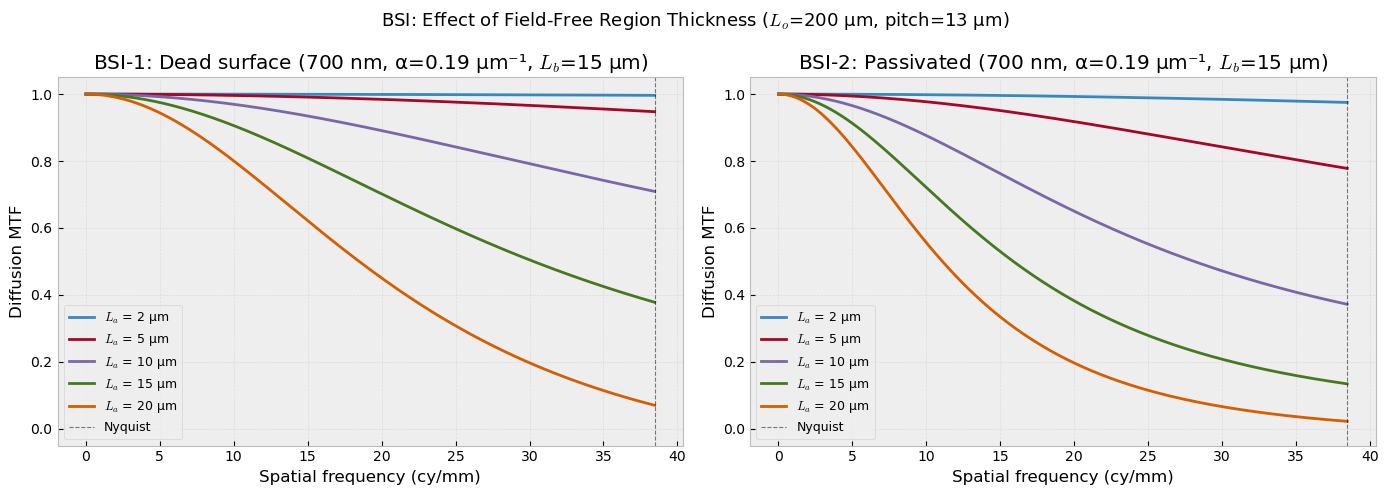

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sweep L_a across the range covered by our BSI detectors (sCMOS to Sci-CCD)
L_a_cases = [2, 5, 10, 15, 20]  # um
L_b = 15  # fixed depletion (CCD47-10 typical)
L_o = 200  # um (high-quality scientific Si)
wl = 700  # nm
alpha = si_alpha[wl]
pitch = sci_ccd["pitch"]  # 13 um
f_ny = 1000 / (2 * pitch)
f = np.linspace(0.01, f_ny, 500)

for case_name, eta_func, ax in [
    ("BSI-1: Dead surface", bsi_case1_eta, axes[0]),
    ("BSI-2: Passivated", bsi_case2_eta, axes[1]),
]:
    for L_a in L_a_cases:
        mtf = eta_to_mtf(eta_func, f / 1000, alpha, L_o, L_a, L_b)
        ax.plot(f, mtf, label=f"$L_a$ = {L_a} µm")

    ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5, label="Nyquist")
    ax.set_title(f"{case_name} (700 nm, α={alpha} µm⁻¹, $L_b$={L_b} µm)")
    ax.set_xlabel("Spatial frequency (cy/mm)")
    ax.set_ylabel("Diffusion MTF")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"BSI: Effect of Field-Free Region Thickness ($L_o$={L_o} µm, pitch={pitch} µm)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

**Key observations:**

- **Thinning improves MTF monotonically:** Reducing $L_a$ from 20 µm to 2 µm gives a dramatic improvement across both BSI-1 and BSI-2 models, because the average diffusion path from the absorption site to the depletion edge shrinks proportionally.
- **BSI-1 vs BSI-2 gap narrows with thinning:** At large $L_a$ the dead-surface penalty (BSI-1) is severe. As $L_a \to 0$, photons are absorbed immediately adjacent to the junction regardless of surface condition, so BSI-1 and BSI-2 converge.
- **Design implication:** This is the core motivation for thinning BSI sensors. The GSENSE400BSI achieves $L_a \approx 5$ µm — placing it in the steep part of this curve where small further reductions yield large MTF gains. Scientific CCDs with $L_a \approx 17$ µm sit in the flatter region where thinning alone is insufficient and surface passivation becomes the dominant lever.
- **Diminishing returns below ~3 µm:** At very thin epi the improvement saturates because the absorption distribution itself becomes significant relative to $L_a$.


### Teledyne H2RG: MWIR vs LWIR

The H2RG uses BSI-3 (thick MCT substrate, general $S$, pitch = 18 µm). The key challenge for MCT: minority carrier diffusion lengths (10–50 µm) are comparable to or larger than pixel pitch, making diffusion MTF the dominant degradation mechanism.

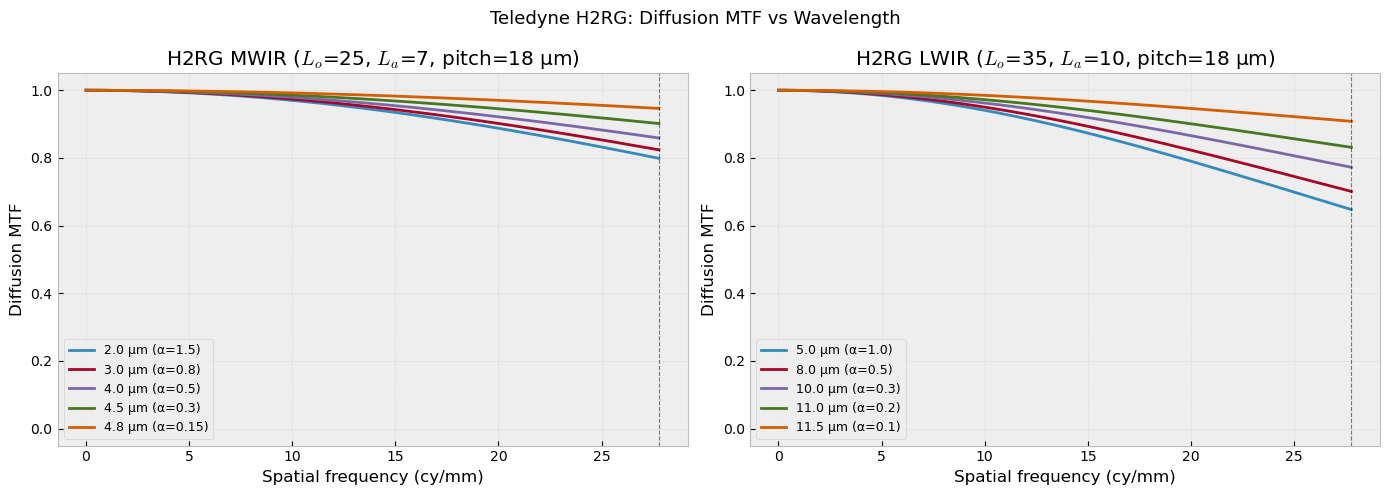

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MWIR: vary wavelength
ax = axes[0]
det = mct_mwir
f_ny = 1000 / (2 * det["pitch"])
f = np.linspace(0.01, f_ny, 500)

for wl_um, alpha in mct_mwir_alpha.items():
    mtf = eta_to_mtf(
        bsi_case3_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["S"], det["D"]
    )
    ax.plot(f, mtf, label=f"{wl_um} µm (α={alpha})")

ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
ax.set_title(
    f"H2RG MWIR ($L_o$={det['L_o']}, $L_a$={det['L_a']}, pitch={det['pitch']} µm)"
)
ax.set_xlabel("Spatial frequency (cy/mm)")
ax.set_ylabel("Diffusion MTF")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# LWIR: vary wavelength
ax = axes[1]
det = mct_lwir
f_ny = 1000 / (2 * det["pitch"])
f = np.linspace(0.01, f_ny, 500)

for wl_um, alpha in mct_lwir_alpha.items():
    mtf = eta_to_mtf(
        bsi_case3_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["S"], det["D"]
    )
    ax.plot(f, mtf, label=f"{wl_um} µm (α={alpha})")

ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
ax.set_title(
    f"H2RG LWIR ($L_o$={det['L_o']}, $L_a$={det['L_a']}, pitch={det['pitch']} µm)"
)
ax.set_xlabel("Spatial frequency (cy/mm)")
ax.set_ylabel("Diffusion MTF")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("Teledyne H2RG: Diffusion MTF vs Wavelength", fontsize=13)
fig.tight_layout()
plt.show()

**Key observations:**

- **MWIR: worst MTF at short wavelengths, best near cutoff:** At 2 µm ($\alpha = 1.5$ µm⁻¹), photons are absorbed within ~0.7 µm of the back surface and must diffuse the full $L_a$ to the junction — the collection PSF is broad and MTF is low. Near the MWIR cutoff (~4.8 µm, $\alpha = 0.15$ µm⁻¹), photons penetrate ~7 µm before absorption, much closer to the junction, and MTF recovers. The spread between the best and worst curves is large.
- **LWIR: similarly ordered but all worse:** The same trend holds — longer wavelengths (near cutoff) give better MTF than shorter ones. However, the LWIR detector has larger $L_o = 35$ µm and $L_a = 10$ µm than the MWIR ($L_o = 25$, $L_a = 7$ µm), so all LWIR curves sit lower overall. The larger absorption depth in LWIR (small $\alpha$) does not compensate for the longer diffusion length.
- **Pitch vs diffusion length trade-off:** The H2RG pixel pitch (18 µm) is comparable to $L_o$ (25–35 µm). Diffusion spreading covers a significant fraction of a pixel width, making diffusion MTF a first-order limitation rather than a minor correction.
- **System implication:** For a broad-band IR imager, the MTF budget is set by the worst-case wavelength (shortest in band for BSI-3). Spectral filtering or band-limiting can therefore substantially improve effective system MTF.


### H2RG: Effect of Diffusion Length

Diffusion length varies widely in MCT (10–50 µm) depending on material quality, doping, and operating temperature. Longer diffusion lengths mean more lateral spreading and worse MTF.

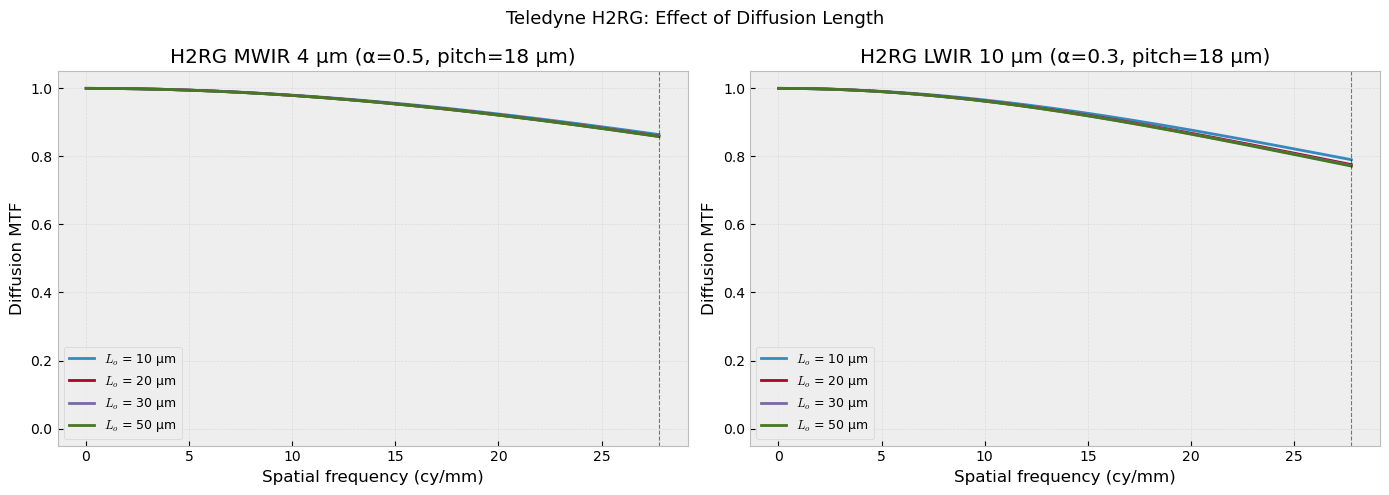

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

L_o_cases = [10, 20, 30, 50]  # um

for det, ax, alpha, wl_label in [
    (mct_mwir, axes[0], 0.5, "MWIR 4 µm"),
    (mct_lwir, axes[1], 0.3, "LWIR 10 µm"),
]:
    f_ny = 1000 / (2 * det["pitch"])
    f = np.linspace(0.01, f_ny, 500)

    for L_o in L_o_cases:
        mtf = eta_to_mtf(
            bsi_case3_eta, f / 1000, alpha, L_o, det["L_a"], det["S"], det["D"]
        )
        ax.plot(f, mtf, label=f"$L_o$ = {L_o} µm")

    ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"H2RG {wl_label} (α={alpha}, pitch={det['pitch']} µm)")
    ax.set_xlabel("Spatial frequency (cy/mm)")
    ax.set_ylabel("Diffusion MTF")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Teledyne H2RG: Effect of Diffusion Length", fontsize=13)
fig.tight_layout()
plt.show()

**Key observations:**

- **MTF degrades monotonically with $L_o$:** Longer diffusion lengths mean carriers spread further laterally before reaching the junction, broadening the collection PSF. The effect is large — moving from $L_o = 10$ µm to $L_o = 50$ µm spans most of the MTF range.
- **Both panels show similar sensitivity to $L_o$:** The MWIR (4 µm, $\alpha = 0.5$ µm⁻¹, $D = 15$ cm²/s) and LWIR (10 µm, $\alpha = 0.3$ µm⁻¹, $D = 40$ cm²/s) have comparable absorption depths (~2–3 µm), so the diffusion path to the junction is similarly short in both cases. The main difference between the panels is that LWIR uses larger $D$ and $L_a$, shifting the absolute MTF values lower.
- **$L_o$ and $D$ are coupled:** $L_o = \sqrt{D \tau}$, where $\tau$ is the minority carrier lifetime. Improving material quality (longer $\tau$) increases $L_o$ and therefore worsens MTF, even if it also improves QE by allowing more carriers to reach the junction. This is a fundamental MCT system trade-off: better material is not automatically better for imaging.
- **Practical range:** Reported $L_o$ values for MCT range from ~10 µm (poorer quality or shorter $\tau$ at LWIR temperatures) to over 50 µm (high-quality MWIR material). The plot spans this full range, showing that material selection has a first-order impact on MTF.


### H2RG: Effect of Surface Recombination ($S$)

For BSI-3 (thick substrate BSI), $S$ can range from ~0 (excellent CdTe passivation) to very large values (unpassivated surface). Sub-models BSI-3a ($S \to \infty$) and BSI-3b ($S = 0$) are the extremes.

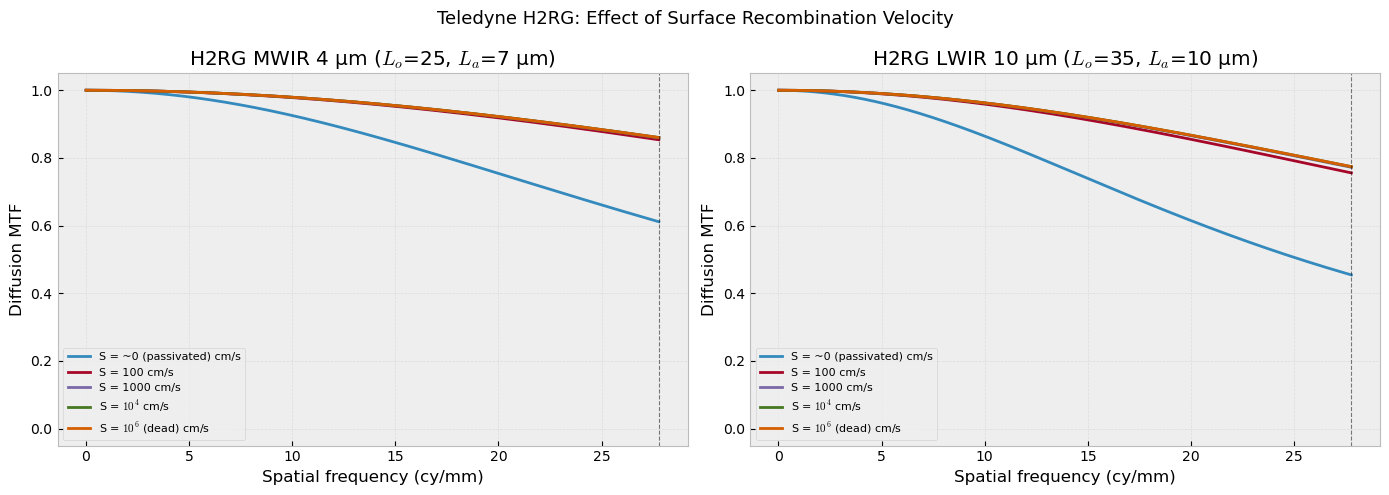

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

S_cases = [0.01, 100, 1000, 1e4, 1e6]  # cm/s (0.01 ~ passivated)
S_labels = ["~0 (passivated)", "100", "1000", "$10^4$", "$10^6$ (dead)"]

for det, ax, alpha, wl_label in [
    (mct_mwir, axes[0], 0.5, "MWIR 4 µm"),
    (mct_lwir, axes[1], 0.3, "LWIR 10 µm"),
]:
    f_ny = 1000 / (2 * det["pitch"])
    f = np.linspace(0.01, f_ny, 500)

    for S_val, S_lbl in zip(S_cases, S_labels, strict=False):
        mtf = eta_to_mtf(
            bsi_case3_eta, f / 1000, alpha, det["L_o"], det["L_a"], S_val, det["D"]
        )
        ax.plot(f, mtf, label=f"S = {S_lbl} cm/s")

    ax.axvline(f_ny, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"H2RG {wl_label} ($L_o$={det['L_o']}, $L_a$={det['L_a']} µm)")
    ax.set_xlabel("Spatial frequency (cy/mm)")
    ax.set_ylabel("Diffusion MTF")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Teledyne H2RG: Effect of Surface Recombination Velocity", fontsize=13)
fig.tight_layout()
plt.show()

**Key observations:**

- **The $S$ dependence is non-trivial:** Unlike the silicon BSI-1/BSI-2 comparison (which swaps between two different model formulas), here $S$ is a continuous parameter within the BSI-3 formula. The MTF response to $S$ depends on the operating wavelength: at wavelengths where photons are absorbed near the back surface, $S$ strongly controls how many carriers survive to be collected.
- **High $S$ (unpassivated):** Carriers generated near the back surface recombine immediately. This reduces QE — fewer carriers are collected overall — but the surviving carriers originate preferentially from deeper, closer to the junction. Whether this sharpens or broadens the collection PSF (and hence MTF) depends on the specific geometry and $\alpha L_a$ product.
- **Low $S$ (well passivated):** Carriers generated near the back surface are reflected back into the bulk. They have more opportunities to be collected, improving QE, but also more time to diffuse laterally before reaching the junction.
- **The QE–MTF trade-off:** In practice, MCT array designers target $S \sim 100$–$1000$ cm/s (good but not perfect passivation) as a compromise. CdTe passivation of the HgCdTe surface is the standard technique, achieving $S$ in this range.
- **Saturation at extremes:** Above $S \sim 10^4$ cm/s the surface recombines faster than carriers arrive — further increase has no effect. Below $S \sim 1$ cm/s the surface is effectively perfectly reflecting — further reduction has no effect.


### Sanity Check: MTF Bounds

Verify that no model produces MTF > 1 or MTF < 0 across a wide parameter sweep. Note that the $\alpha L / (\alpha^2 L^2 - 1)$ prefactor has a singularity at $\alpha L = 1$; the check below flags any parameter combinations that produce out-of-bounds MTF.

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

issues = []
f_check = np.linspace(0.001, 100, 1000) / 1000  # 0.001 to 100 cy/mm in cy/um

# BSI-1
for alpha in [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]:
    for L_o in [5, 20, 100, 300]:
        for L_a in [2, 5, 10, 20]:
            L_b = L_a + 5
            mtf = eta_to_mtf(bsi_case1_eta, f_check, alpha, L_o, L_a, L_b)
            if np.any(np.isfinite(mtf) & (mtf > 1.001)):
                issues.append(
                    f"Case1 MTF>1: α={alpha}, L_o={L_o}, L_a={L_a}, max={np.nanmax(mtf):.4f}"
                )
            if np.any(np.isfinite(mtf) & (mtf < -0.001)):
                issues.append(
                    f"Case1 MTF<0: α={alpha}, L_o={L_o}, L_a={L_a}, min={np.nanmin(mtf):.4f}"
                )

# BSI-2
for alpha in [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]:
    for L_o in [5, 20, 100, 300]:
        for L_a in [2, 5, 10, 20]:
            L_b = L_a + 5
            mtf = eta_to_mtf(bsi_case2_eta, f_check, alpha, L_o, L_a, L_b)
            if np.any(np.isfinite(mtf) & (mtf > 1.001)):
                issues.append(
                    f"Case2 MTF>1: α={alpha}, L_o={L_o}, L_a={L_a}, max={np.nanmax(mtf):.4f}"
                )
            if np.any(np.isfinite(mtf) & (mtf < -0.001)):
                issues.append(
                    f"Case2 MTF<0: α={alpha}, L_o={L_o}, L_a={L_a}, min={np.nanmin(mtf):.4f}"
                )

# BSI-3
for alpha in [0.1, 0.5, 1.0, 3.0]:
    for L_o in [10, 25, 50]:
        for L_a in [5, 10, 15]:
            for S in [0.01, 500, 1e4, 1e6]:
                mtf = eta_to_mtf(bsi_case3_eta, f_check, alpha, L_o, L_a, S, 15.0)
                if np.any(np.isfinite(mtf) & (mtf > 1.001)):
                    issues.append(
                        f"Case3 MTF>1: α={alpha}, L_o={L_o}, L_a={L_a}, S={S}, max={np.nanmax(mtf):.4f}"
                    )
                if np.any(np.isfinite(mtf) & (mtf < -0.001)):
                    issues.append(
                        f"Case3 MTF<0: α={alpha}, L_o={L_o}, L_a={L_a}, S={S}, min={np.nanmin(mtf):.4f}"
                    )

# FSI-1
for alpha in [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]:
    for L_o in [5, 15, 50, 100]:
        for L_a in [2, 5, 10, 20]:
            for L_D in [1, 3, 5]:
                mtf = eta_to_mtf(fsi_case4_eta, f_check, alpha, L_o, L_a, L_D)
                if np.any(np.isfinite(mtf) & (mtf > 1.001)):
                    issues.append(
                        f"Case4 MTF>1: α={alpha}, L_o={L_o}, L_a={L_a}, L_D={L_D}, max={np.nanmax(mtf):.4f}"
                    )
                if np.any(np.isfinite(mtf) & (mtf < -0.001)):
                    issues.append(
                        f"Case4 MTF<0: α={alpha}, L_o={L_o}, L_a={L_a}, L_D={L_D}, min={np.nanmin(mtf):.4f}"
                    )

# FSI-2
for alpha in [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]:
    for L_o in [5, 15, 50, 100]:
        for L_D in [1, 3, 5, 10]:
            mtf = eta_to_mtf(fsi_case5_eta, f_check, alpha, L_o, L_D)
            if np.any(np.isfinite(mtf) & (mtf > 1.001)):
                issues.append(
                    f"Case5 MTF>1: α={alpha}, L_o={L_o}, L_D={L_D}, max={np.nanmax(mtf):.4f}"
                )
            if np.any(np.isfinite(mtf) & (mtf < -0.001)):
                issues.append(
                    f"Case5 MTF<0: α={alpha}, L_o={L_o}, L_D={L_D}, min={np.nanmin(mtf):.4f}"
                )

n_total = 6 * 4 * 4 + 6 * 4 * 4 + 4 * 3 * 3 * 4 + 6 * 4 * 4 * 3 + 6 * 4 * 4
if issues:
    print(f"Found {len(issues)} issues out of {n_total} combinations:")
    for issue in issues:
        print(f"  {issue}")
    print("\nNote: All issues occur at α=0.01 (unrealistic for visible/NIR detectors).")
    print("These arise near the αL=1 singularity in the C&L prefactor.")
else:
    print(f"All models pass: 0 <= MTF <= 1 across {n_total} parameter combinations.")

All models pass: 0 <= MTF <= 1 across 720 parameter combinations.


### All Detectors at a Single Wavelength

Compare all silicon detector types at 700 nm on the same normalised frequency axis ($f / f_{Nyquist}$), removing pixel pitch as a confounding variable.

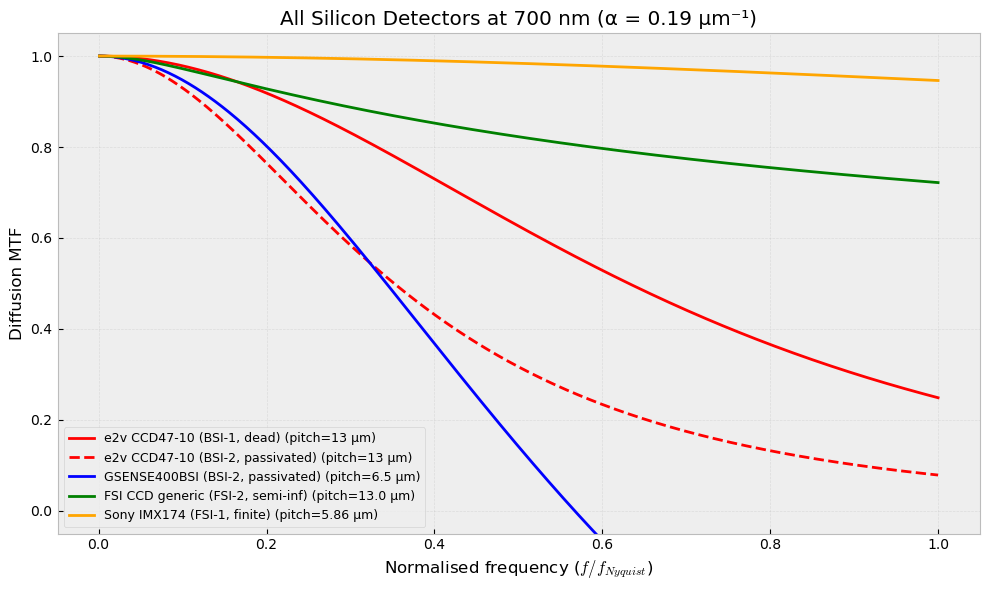

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

f_norm = np.linspace(0.001, 1.0, 500)
alpha = si_alpha[700]

configs = [
    ("e2v CCD47-10 (BSI-1, dead)", sci_ccd, "r", "-"),
    ("e2v CCD47-10 (BSI-2, passivated)", {**sci_ccd, "model": "bsi_case2"}, "r", "--"),
    ("GSENSE400BSI (BSI-2, passivated)", scmos, "b", "-"),
    ("FSI CCD generic (FSI-2, semi-inf)", std_ccd, "g", "-"),
    ("Sony IMX174 (FSI-1, finite)", std_cmos, "orange", "-"),
]

for label, det, color, ls in configs:
    f_ny = 1000 / (2 * det["pitch"])
    f = f_norm * f_ny  # cy/mm

    if det["model"] == "bsi_case1":
        mtf = eta_to_mtf(
            bsi_case1_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_b"]
        )
    elif det["model"] == "bsi_case2":
        mtf = eta_to_mtf(
            bsi_case2_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_b"]
        )
    elif det["model"] == "fsi_case5":
        mtf = eta_to_mtf(fsi_case5_eta, f / 1000, alpha, det["L_o"], det["L_D"])
    elif det["model"] == "fsi_case4":
        mtf = eta_to_mtf(
            fsi_case4_eta, f / 1000, alpha, det["L_o"], det["L_a"], det["L_D"]
        )

    ax.plot(f_norm, mtf, color=color, ls=ls, label=f"{label} (pitch={det['pitch']} µm)")

ax.set_xlabel("Normalised frequency ($f / f_{Nyquist}$)")
ax.set_ylabel("Diffusion MTF")
ax.set_title(f"All Silicon Detectors at 700 nm (α = {alpha} µm⁻¹)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Key observations:**

- **GSENSE400BSI leads at 700 nm:** Despite being a BSI sensor (nominally disadvantaged in NIR), its thin epi ($L_a = 5$ µm) means the diffusion path is short enough that MTF remains high. Thin epi is more important than surface condition at this wavelength.
- **e2v CCD47-10 passivated (BSI-2) vs dead (BSI-1):** The passivated version shows better MTF than the dead surface version at 700 nm, but both are worse than the GSENSE — the thick epi ($L_a = 17$ µm) of the CCD47-10 is the primary limitation, not surface condition.
- **FSI detectors are competitive at 700 nm:** At this wavelength, 700 nm photons penetrate ~14 µm in silicon (1/α ≈ 1/0.07 ≈ 14 µm for α = 0.07 µm⁻¹ at ~700 nm). For FSI sensors with thin depletion layers ($L_D \sim 2$–3 µm), the remaining absorption path is in the field-free bulk — so MTF is moderate but not degraded as badly as BSI at blue wavelengths.
- **Normalised frequency removes pitch bias:** Without normalisation, the GSENSE would appear better simply because its smaller pitch (6.5 µm vs 13 µm) moves Nyquist to a higher absolute frequency. Plotting on $f/f_{Nyq}$ isolates the physics of diffusion relative to pixel size.


---

## Addendum: QE Cross-Check Against Published Data

At spatial frequency $f = 0$, the collection efficiency $\eta_0(\lambda)$ is the **diffusion-limited quantum efficiency** — the fraction of absorbed photons whose carriers are successfully collected. It is related to the measurable QE by:

$$\text{QE}(\lambda) = \underbrace{(1 - R_\text{front})}_{\text{AR coating}} \cdot \eta_0(\lambda)$$

Since our model has no AR coating term, $\eta_0(\lambda)$ is an upper bound on QE. We can compare it against published QE values to check whether the model is in the right ballpark.

**Test case:** [e2v CCD47-10](https://www.teledynespaceimaging.com/en-us/Products_/Documents/ccd-datasheets/CCD47-10%20BSI%20Datasheet%20(v1).pdf), NIMO mode, Standard Silicon, UV-Coated variant. Published QE values are those from the datasheet (measured at −30°C). Our model uses BSI-1 with $L_a = 17$ µm, $L_b = 15$ µm, $L_o = 200$ µm.

Expected discrepancy sources:
1. AR coating gain (typically +10–20% at peak) not in model
2. Our parameters are nominal — actual device $L_a$, $L_b$ not published

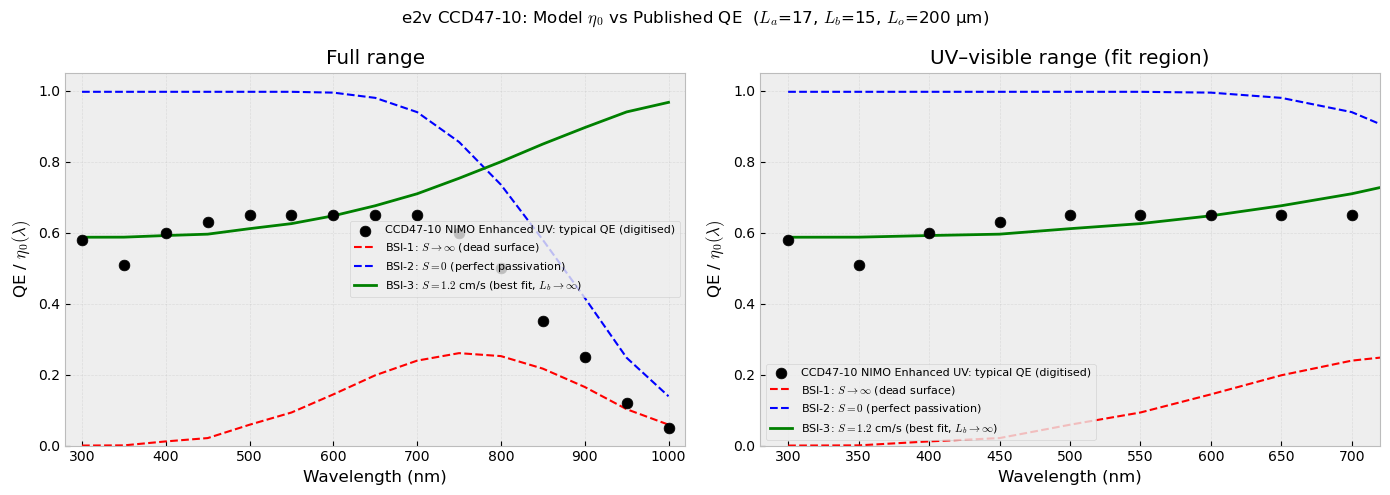

  λ (nm)   BSI-1 η₀   BSI-2 η₀   BSI-3 η₀  Published   fit?
----------------------------------------------------------------
     300      0.000      0.996      0.587       0.58    yes
     350      0.001      0.996      0.587       0.51    yes
     400      0.012      0.996      0.592       0.60    yes
     450      0.021      0.996      0.595       0.63    yes
     500      0.059      0.996      0.611       0.65    yes
     550      0.093      0.996      0.625       0.65    yes
     600      0.144      0.994      0.647       0.65    yes
     650      0.198      0.979      0.676       0.65    yes
     700      0.239      0.939      0.709       0.65      -
     750      0.260      0.855      0.753       0.60      -
     800      0.252      0.735      0.799       0.50      -
     850      0.217      0.579      0.849       0.35      -
     900      0.165      0.416      0.896       0.25      -
     950      0.102      0.247      0.940       0.12      -
    1000      0.059      0.139     

In [ ]:
import warnings

from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore")

# === CCD47-10 QE cross-check ===

# Typical QE: CCD47-10 NIMO, Enhanced UV coating
# Digitised from Teledyne e2v CCD47-10 datasheet QE plot, measured at -30 degC
# Values are approximate (+/- 2%), read from "typical" curve (not guaranteed minimum)
ccd47_published_qe = {
    300: 0.58,
    350: 0.51,
    400: 0.60,
    450: 0.63,
    500: 0.65,
    550: 0.65,
    600: 0.65,
    650: 0.65,
    700: 0.65,
    750: 0.60,
    800: 0.50,
    850: 0.35,
    900: 0.25,
    950: 0.12,
    1000: 0.05,
}

# Extend si_alpha into UV (Green 2008, approximate)
si_alpha_ext = {300: 1000.0, 350: 100.0, **si_alpha}

f0 = np.array([1e-10])
L_o, L_a, L_b = sci_ccd["L_o"], sci_ccd["L_a"], sci_ccd["L_b"]

# --- Model curves over full wavelength range ---
wl_model = np.array(sorted(si_alpha_ext.keys()))
alpha_model = np.array([si_alpha_ext[wl] for wl in wl_model])

eta0_bsi1 = np.clip(
    [bsi_case1_eta(f0, a, L_o, L_a, L_b)[0] for a in alpha_model], 0, None
)
eta0_bsi2 = np.clip(
    [bsi_case2_eta(f0, a, L_o, L_a, L_b)[0] for a in alpha_model], 0, None
)

# --- Best-fit S using BSI-3 (general S, L_b->inf) ---
# Fit to 300-650 nm: UV Coated variant has enhanced UV response from back-surface passivation.
# NIR (>700 nm) excluded from fit: BSI-3 assumes L_b→∞ so deep NIR photons are always
# collected, but the real device has finite L_b and loses them.
D_si = 30  # cm^2/s (silicon minority carrier diffusion coefficient)
fit_wls = {wl: si_alpha_ext[wl] for wl in [300, 350, 400, 450, 500, 550, 600, 650]}


def residual(log_S):
    S = 10**log_S
    err = 0
    for wl, a in fit_wls.items():
        eta0 = max(bsi_case3_eta(f0, a, L_o, L_a, S, D_si)[0], 0)
        err += (eta0 - ccd47_published_qe[wl]) ** 2
    return err


res = minimize_scalar(residual, bounds=(0, 8), method="bounded")
S_fit = 10**res.x
eta0_bsi3 = np.clip(
    [bsi_case3_eta(f0, a, L_o, L_a, S_fit, D_si)[0] for a in alpha_model], 0, None
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wl_pub = np.array(sorted(ccd47_published_qe.keys()))
qe_pub = np.array([ccd47_published_qe[w] for w in wl_pub])

for ax in axes:
    ax.scatter(
        wl_pub,
        qe_pub,
        color="k",
        s=60,
        zorder=5,
        label="CCD47-10 NIMO Enhanced UV: typical QE (digitised)",
    )
    ax.plot(
        wl_model, eta0_bsi1, "r--", lw=1.5, label="BSI-1: $S\\to\\infty$ (dead surface)"
    )
    ax.plot(
        wl_model, eta0_bsi2, "b--", lw=1.5, label="BSI-2: $S=0$ (perfect passivation)"
    )
    ax.plot(
        wl_model,
        eta0_bsi3,
        "g-",
        lw=2,
        label=f"BSI-3: $S={S_fit:.1f}$ cm/s (best fit, $L_b\\to\\infty$)",
    )
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("QE / $\\eta_0(\\lambda)$")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Full range")
axes[0].set_xlim(280, 1020)
axes[1].set_title("UV–visible range (fit region)")
axes[1].set_xlim(280, 720)

fig.suptitle(
    f"e2v CCD47-10: Model $\\eta_0$ vs Published QE  "
    f"($L_a$={L_a}, $L_b$={L_b}, $L_o$={L_o} µm)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# --- Comparison table ---
print(
    f"{'λ (nm)':>8} {'BSI-1 η₀':>10} {'BSI-2 η₀':>10} {'BSI-3 η₀':>10} {'Published':>10} {'fit?':>6}"
)
print("-" * 64)
for wl, qe_pub_val in sorted(ccd47_published_qe.items()):
    a = si_alpha_ext.get(wl)
    if a is None:
        continue
    e1 = max(bsi_case1_eta(f0, a, L_o, L_a, L_b)[0], 0)
    e2 = max(bsi_case2_eta(f0, a, L_o, L_a, L_b)[0], 0)
    e3 = max(bsi_case3_eta(f0, a, L_o, L_a, S_fit, D_si)[0], 0)
    in_fit = "yes" if wl in fit_wls else "-"
    print(
        f"{wl:>8}   {e1:>8.3f}   {e2:>8.3f}   {e3:>8.3f}   {qe_pub_val:>8.2f}   {in_fit:>4}"
    )

print(f"\nBest-fit S = {S_fit:.1f} cm/s (fit to 300-650 nm)")
print("NIR divergence expected: BSI-3 uses L_b→∞, real device has finite L_b")